# **TP — Implémentation d’un Mini Réseau de Neurones avec NumPy**
> **But :** ce TP a pour objectif d’introduire, à l’aide de **NumPy** et **Matplotlib**, les bases de l’implémentation d’un mini réseau de neurones *from scratch*.  
> Dans une première partie, il s’agit d’implémenter et de visualiser plusieurs **fonctions d’activation** (ReLU, Sigmoid, Tanh, LeakyReLU, puis Softplus et ELU), en produisant :
> 1. un **tracé comparatif** des fonctions sur une même figure,
> 2. une **grille de sous-figures** pour visualiser chaque fonction séparément.
>
> Dans une deuxième partie, il s’agit d’implémenter un **mini réseau de neurones 2 → 3 → 1** en NumPy pour apprendre la fonction **XOR**, en détaillant :
> - la **propagation avant**,
> - la **fonction de perte**,
> - la **rétropropagation des gradients**,
> - l’**entraînement par descente de gradient**,
> - puis l’extension à un **dataset XOR bruité** avec données perturbées et labels erronés.
>
> Enfin, le TP vise à évaluer le modèle appris à l’aide de métriques de classification telles que :
> - **Accuracy**
> - **Precision**
> - **Recall**
> - **F1-score**
> - **Matrice de confusion**
> - **Courbe ROC** et **AUC**

## 1) Objectifs pédagogiques

A l’issue de ce TP, l’étudiant devra être capable de :
- implémenter des fonctions d’activation
- manipuler les produits matriciels NumPy
- comprendre les shapes des matrices
- implémenter un réseau de neurones 2 → 3 → 1
- implémenter la backpropagation
- entraîner un modèle pour apprendre XOR
- évaluer un modèle avec accuracy, precision, recall, F1
- analyser un modèle avec matrice de confusion et ROC curve
- comprendre l’effet du bruit dans les données

---

## 2) Pré-requis

- Python 3.x
- Bibliothèques : `numpy`, `matplotlib`, `scipy`

---

## Partie A : Mini Réseau de Neurones pour XOR
### I — Mise en place

#### I.1. Imports et création du dataset (vecteur `x`)

##### ✅ À faire
- Importer `numpy` et `matplotlib.pyplot`
- Créer `x` avec **600 points** entre `-3` et `3`

In [1]:
# TODO
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(start=-3,stop=3,num=600)
x

array([-3.        , -2.98998331, -2.97996661, -2.96994992, -2.95993322,
       -2.94991653, -2.93989983, -2.92988314, -2.91986644, -2.90984975,
       -2.89983306, -2.88981636, -2.87979967, -2.86978297, -2.85976628,
       -2.84974958, -2.83973289, -2.82971619, -2.8196995 , -2.8096828 ,
       -2.79966611, -2.78964942, -2.77963272, -2.76961603, -2.75959933,
       -2.74958264, -2.73956594, -2.72954925, -2.71953255, -2.70951586,
       -2.69949917, -2.68948247, -2.67946578, -2.66944908, -2.65943239,
       -2.64941569, -2.639399  , -2.6293823 , -2.61936561, -2.60934891,
       -2.59933222, -2.58931553, -2.57929883, -2.56928214, -2.55926544,
       -2.54924875, -2.53923205, -2.52921536, -2.51919866, -2.50918197,
       -2.49916528, -2.48914858, -2.47913189, -2.46911519, -2.4590985 ,
       -2.4490818 , -2.43906511, -2.42904841, -2.41903172, -2.40901503,
       -2.39899833, -2.38898164, -2.37896494, -2.36894825, -2.35893155,
       -2.34891486, -2.33889816, -2.32888147, -2.31886477, -2.30

#### I.2. Dictionnaires des fonctions d’activation et de leurs dérivées

##### ✅ À faire

Définir deux dictionnaires :

- `activations` : contenant les **fonctions d’activation**
- `d_activations` : contenant leurs **dérivées**, nécessaires pour la **backpropagation**

Ces fonctions sont utilisées dans les **réseaux de neurones** pour introduire de la **non-linéarité** dans le modèle.

---

### 1️⃣ ReLU (Rectified Linear Unit)

Fonction d’activation :

$$
f(x)=\max(0,x)
$$

Dérivée :

$$
f'(x)=
\begin{cases}
1 & \text{si } x>0 \\
0 & \text{sinon}
\end{cases}
$$

Cette fonction est très utilisée dans les réseaux profonds car :
- elle est **simple**
- elle **accélère l’apprentissage**

---

### 2️⃣ Sigmoid

Fonction d’activation :

$$
f(x)=\frac{1}{1+e^{-x}}
$$

Cette fonction transforme toute valeur réelle en **probabilité dans l’intervalle [0,1]**.

Elle est donc souvent utilisée pour la **sortie des modèles de classification binaire**.

---

#### Forme stable numériquement

Pour éviter les problèmes d’overflow lorsque \(x\) est très grand en valeur absolue :

$$
f(x)=
\begin{cases}
\dfrac{1}{1+e^{-x}} & \text{si } x \ge 0 \\
\dfrac{e^x}{1+e^x} & \text{sinon}
\end{cases}
$$

---

#### Dérivée

Si :

$$
s=f(x)
$$

alors :

$$
f'(x)=s(1-s)
$$

Cette forme est très pratique car elle utilise **la sortie déjà calculée**.

---

### 3️⃣ Tanh (Hyperbolic Tangent)

Fonction d’activation :

$$
f(x)=\tanh(x)
$$

Elle renvoie des valeurs dans l’intervalle :

$$
(-1,1)
$$

Elle est souvent préférée à sigmoid dans les **couches cachées** car elle est **centrée autour de zéro**.

---

#### Dérivée

Si :

$$
a=\tanh(x)
$$

alors :

$$
f'(x)=1-a^2
$$

---

### 4️⃣ LeakyReLU

Contrairement à ReLU, cette fonction garde une **petite pente dans la zone négative**.

Avec \(a=0.1\) :

$$
f(x)=
\begin{cases}
x & \text{si } x>0 \\
ax & \text{sinon}
\end{cases}
$$

---

#### Dérivée

$$
f'(x)=
\begin{cases}
1 & \text{si } x>0 \\
a & \text{sinon}
\end{cases}
$$

---

### 🔎 Remarque importante pour l’implémentation

Dans le **backpropagation**, certaines dérivées sont calculées à partir de la **sortie de la fonction d’activation** plutôt qu’à partir de \(x\).

Exemples :

- pour **Sigmoid** :

$$
\sigma'(x)=\sigma(x)(1-\sigma(x))
$$

- pour **Tanh** :

$$
\tanh'(x)=1-\tanh^2(x)
$$

Ainsi, dans le code Python, on peut écrire les dérivées en fonction de la **sortie déjà calculée**, ce qui évite de recalculer l’activation.

In [2]:
# TODO
# activations
activations = {
    "Relu": lambda x: np.maximum(0,x),
    "Sigmoid": lambda x: 1 / (1+np.exp(-x)),
    "Sigmoid_stable": lambda x: np.where(
        x>=0,
        (1/(1+np.exp(-x))),
        np.exp(x)/(1+np.exp(x))
    ),
    "Tanh": lambda x: np.tanh(x),
    "LeakyRelu": lambda x, a=0.1:np.maximum(a*x, x)
}
# --- dérivées  ---
d_activations = {
    "Relu": lambda x: np.where(x>0, 1,0),
    "Sigmoid": lambda x: (lambda s: s * (1 - s))(activations["Sigmoid"](x)),
    "Sigmoid_stable":lambda x: (lambda s: s * (1 - s))(activations["Sigmoid_stable"](x)),
    "Tanh":lambda x: 1 - np.tanh(x)**2,
    "LeakyRelu": lambda x, a=0.1 : np.where(x > 0, 1, a)
}

---
#### I.4. Dictionnaires style des courbes (couleurs des courbes et marqueurs) : 
##### ✅ A faire :
- utiliser une couleur distincte par courbe :
    Codes couleurs : `["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]`
- utiliser un marqueur distinct  par courbe :
    Codes marqueurs : 
    - `"o"` : cercle  
    - `"s"` : carré  
    - `"^"` : triangle haut  
    - `"v"` : triangle bas  
    - `"D"` : losange  
    - `"x"` | `"+"` : croix  
    - `"*"` : étoile  
    - `"."` : point  

In [3]:
couleurs = {
    "Relu": "tab:blue",
    "Sigmoid": "tab:orange",
    "Sigmoid_stable": "tab:green",
    "Tanh": "tab:red",
    "LeakyRelu": "tab:pink"
}

markers = {
    "Relu": "o",
    "Sigmoid": "s",
    "Sigmoid_stable": "^",
    "Tanh": "+",
    "LeakyRelu": "*"
}

---
### II. Tracé comparatif sur 1 seule figure
#### A Faire :
Tracer les 4 activations sur **le même graphique**, avec :
- `plot`
- `label`, `color`, `marker`, `markersize`, `markevery`
- `title`, `xlabel`, `ylabel`, `grid`, `legend`, `show`

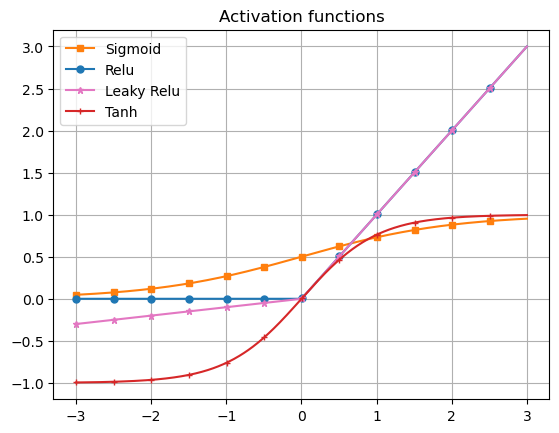

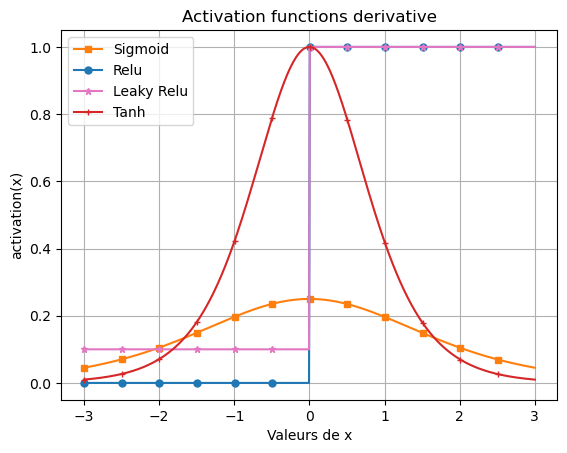

In [4]:
# TODO

plt.figure(1)
plt.title("Activation functions")
plt.plot(x, activations["Sigmoid"](x), couleurs["Sigmoid"], 
         marker = markers["Sigmoid"], markersize = 5, markevery = 50, label = "Sigmoid")
plt.plot(x, activations["Relu"](x), couleurs["Relu"], marker = markers["Relu"], 
         markersize = 5, markevery = 50, label = "Relu")
plt.plot(x, activations["LeakyRelu"](x), couleurs["LeakyRelu"], 
         marker = markers["LeakyRelu"], markersize = 5, markevery = 50, label = "Leaky Relu")
plt.plot(x, activations["Tanh"](x), couleurs["Tanh"], marker = markers["Tanh"], 
         markersize = 5, markevery = 50, label = "Tanh")
plt.legend()
plt.grid()

plt.figure(2)
plt.title("Activation functions derivative")
plt.plot(x, d_activations["Sigmoid"](x), couleurs["Sigmoid"], 
         marker = markers["Sigmoid"], markersize = 5, markevery = 50, label = "Sigmoid")
plt.plot(x, d_activations["Relu"](x), couleurs["Relu"], marker = markers["Relu"], 
         markersize = 5, markevery = 50, label = "Relu")
plt.plot(x, d_activations["LeakyRelu"](x), couleurs["LeakyRelu"], 
         marker = markers["LeakyRelu"], markersize = 5, markevery = 50, label = "Leaky Relu")
plt.plot(x, d_activations["Tanh"](x), couleurs["Tanh"], marker = markers["Tanh"], 
         markersize = 5, markevery = 50, label = "Tanh")
plt.legend()
plt.grid()

plt.xlabel("Valeurs de x")
plt.ylabel("activation(x)")
plt.show()

---
### III. subplots(2x2) pour le Tracé de chaque fonction sur une sous figure 
#### ✅ A faire :
- Créer une grille 2×2 avec `plt.subplots(2,2, ...)` avec : `figsize`, `sharex`, `sharey`
- Aplatir `axes` avec `axes.ravel()`
- Tracer une activation par subplot avec `ax.plot(...)`
- Ajouter titre, labels, grille, légende dans chaque axe
- Utiliser `plt.tight_layout()` et `plt.show()` pour ajuster et afficher la figure


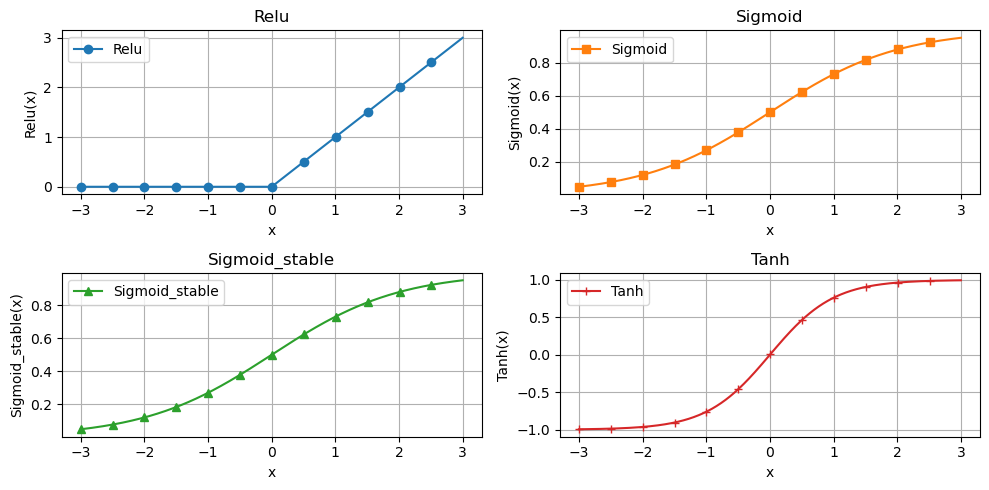

In [5]:
# TODO
fig, axes = plt.subplots(2,2, figsize = (10,5), sharex=False, sharey=False)
flat_ax = axes.ravel()

for ax, name, activation, couleur, marker in zip(flat_ax, activations.keys(), activations.values(), couleurs.values(), markers.values()):
    ax.plot(x, activation(x), color = couleur, label = name, marker = marker, markevery = 50)
    ax.set_ylabel(f"{name}(x)")
    ax.set_xlabel("x")
    ax.set_title(name)
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()


---
### IV. Extension 1 — Ajout de deux fonctions d’activation supplémentaires

#### IV.1. Ajouter les fonctions d’activation suivantes :

---

### 5️⃣ Softplus

Fonction d’activation :

$$
f(x)=\ln(1+e^x)
$$

Cette fonction est une **version lisse de ReLU**.  
Elle est continue et dérivable partout.

---

#### Dérivée (par rapport à l’input)

$$
f'(x)=\frac{e^x}{1+e^x}
$$

On reconnaît la **fonction sigmoid** :

$$
f'(x)=\sigma(x)
$$

---

#### Dérivée (forme pratique pour l’implémentation)

Dans l’implémentation NumPy, on peut calculer la dérivée directement avec :

$$
f'(x)=\sigma(x)
$$


### 6️⃣ ELU (Exponential Linear Unit)

Avec $ \alpha = 1 $.

#### Fonction d’activation

$$
f(x)=
\begin{cases}
x & \text{si } x>0 \\
\alpha(e^x-1) & \text{sinon}
\end{cases}
$$

---

#### Dérivée (par rapport à l’input)

$$
f'(x)=
\begin{cases}
1 & \text{si } x>0 \\
\alpha e^x & \text{sinon}
\end{cases}
$$

---

#### Dérivée (forme pratique en fonction de l’output)

Si

$$
a=f(x)
$$

alors, pour $x \le 0$ :

$$
a=\alpha(e^x-1)
$$

donc :

$$
f'(x)=a+\alpha
$$

Ainsi :

$$
f'(x)=
\begin{cases}
1 & \text{si } x>0 \\
a+\alpha & \text{si } x\le0
\end{cases}
$$

Cette forme peut être utilisée si l’on dispose déjà de l’output de la fonction ELU.

---

### 🔎 Remarque pédagogique

Dans les réseaux de neurones, les dérivées sont souvent exprimées en fonction de la **sortie de l’activation** pour éviter de recalculer l’activation.

Exemples déjà utilisés dans ce TP :

Exemples déjà utilisés dans ce TP :

| Fonction | $f(x)$ | Dérivée utilisée |
|----------|--------|------------------|
| Sigmoid | $f(x)=\dfrac{1}{1+e^{-x}}$ | $f'(x)=s(1-s)$ avec $s=f(x)$ |
| Tanh | $f(x)=\tanh(x)$ | $f'(x)=1-a^2$ avec $a=f(x)$ |
| ReLU | $f(x)=\max(0,x)$ | dépend directement de $x$ |
| LeakyReLU | $f(x)=\begin{cases}x & \text{si } x>0 \\ ax & \text{sinon}\end{cases}$ | dépend directement de $x$ |
| Softplus | $f(x)=\ln(1+e^x)$ | $f'(x)=\sigma(x)$ |
| ELU | $f(x)=\begin{cases}x & \text{si } x>0 \\ \alpha(e^x-1) & \text{sinon}\end{cases}$ | $f'(x)=a+\alpha$ si $x\le0$ |

In [6]:
# TODO
# New activations
activations.update({"Softplus": lambda x: np.log(1+np.exp(x))})
activations.update({"Elu": lambda x, alpha = 1: np.where(x>0, x, alpha*(np.exp(x) - 1.0))})                                                 
# Derivatives
d_activations.update({"Softplus": lambda x: np.exp(x)/(1+np.exp(x))})
d_activations.update({"Elu" : lambda x, alpha=1.0: np.where(x > 0, 1.0, alpha * np.exp(x))})

In [7]:
#couleur
couleurs.update({"Softplus" : "tab:brown"})
couleurs.update({"Elu" : "tab:cyan"})

#markers
markers.update({"Softplus" : "D"})
markers.update({"Elu" : "v"})

---
#### IV.2. tracé comparatif des courbes des fonctions d'activation et de leur dérivées :
##### ✅ La fonction devra
- créer une figure en deux sous graphes avec `plt.subplots(2, 1, ...)`
- Pour chaque sous graphe, tracer  :
  - les fonctions `activations`
  - les fonctions dérivées 
- pour chaque sous-graphe, tracer la courbe avec :
  - `plot`, `label`, `color`, `marker`, `markersize`, `markevery`
- ajouter :
  - `xlabel`, `ylabel`, `legend`, `grid`
- masquer automatiquement les sous-graphes inutilisés si le nombre total de cases est supérieur au nombre de fonctions à tracer

---

##### ✅ Cas particulier des dérivées
Dans le dictionnaire `d_activations`, chaque dérivée est associée à une information indiquant si elle doit être calculée :

- à partir de l’**input** (`"z"`)
- ou à partir de l’**output** (`"out"`)

Ainsi :

- si la dérivée est définie par rapport à `"z"`, on l’évalue directement sur `x`
- si la dérivée est définie par rapport à `"out"`, on doit :
  1. calculer d’abord l’activation correspondante
  2. puis appliquer la dérivée à cette sortie

---

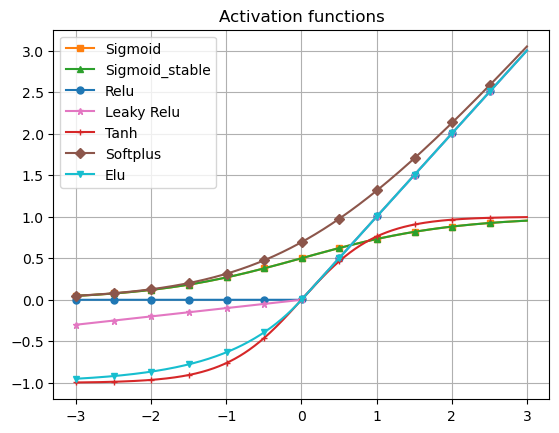

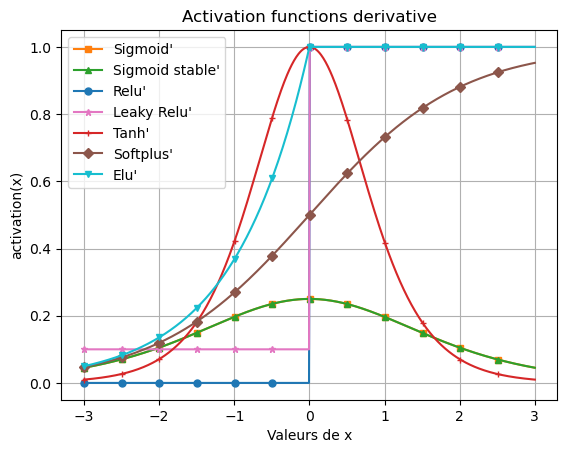

In [8]:
# TODO

plt.figure(1)
plt.title("Activation functions")
plt.plot(x, activations["Sigmoid"](x), couleurs["Sigmoid"], 
         marker = markers["Sigmoid"], markersize = 5, markevery = 50, label = "Sigmoid")
plt.plot(x, activations["Sigmoid_stable"](x), couleurs["Sigmoid_stable"], 
         marker = markers["Sigmoid_stable"], markersize = 5, markevery = 50, label = "Sigmoid_stable")
plt.plot(x, activations["Relu"](x), couleurs["Relu"], marker = markers["Relu"], 
         markersize = 5, markevery = 50, label = "Relu")
plt.plot(x, activations["LeakyRelu"](x), couleurs["LeakyRelu"], 
         marker = markers["LeakyRelu"], markersize = 5, markevery = 50, label = "Leaky Relu")
plt.plot(x, activations["Tanh"](x), couleurs["Tanh"], marker = markers["Tanh"], 
         markersize = 5, markevery = 50, label = "Tanh")
plt.plot(x, activations["Softplus"](x), couleurs["Softplus"], marker = markers["Softplus"], 
         markersize = 5, markevery = 50, label = "Softplus")
plt.plot(x, activations["Elu"](x), couleurs["Elu"], marker = markers["Elu"], 
         markersize = 5, markevery = 50, label = "Elu")
plt.grid()
plt.legend()


plt.figure(2)
plt.title("Activation functions derivative")
plt.plot(x, d_activations["Sigmoid"](x), couleurs["Sigmoid"], 
         marker = markers["Sigmoid"], markersize = 5, markevery = 50, label = "Sigmoid'")
plt.plot(x, d_activations["Sigmoid_stable"](x), couleurs["Sigmoid_stable"], 
         marker = markers["Sigmoid_stable"], markersize = 5, markevery = 50, label = "Sigmoid stable'")
plt.plot(x, d_activations["Relu"](x), couleurs["Relu"], marker = markers["Relu"], 
         markersize = 5, markevery = 50, label = "Relu'")
plt.plot(x, d_activations["LeakyRelu"](x), couleurs["LeakyRelu"], 
         marker = markers["LeakyRelu"], markersize = 5, markevery = 50, label = "Leaky Relu'")
plt.plot(x, d_activations["Tanh"](x), couleurs["Tanh"], marker = markers["Tanh"], 
         markersize = 5, markevery = 50, label = "Tanh'")
plt.plot(x, d_activations["Softplus"](x), couleurs["Softplus"], marker = markers["Softplus"], 
         markersize = 5, markevery = 50, label = "Softplus'")
plt.plot(x, d_activations["Elu"](x), couleurs["Elu"], marker = markers["Elu"], 
         markersize = 5, markevery = 50, label = "Elu'")
plt.grid()
plt.legend()


plt.xlabel("Valeurs de x")
plt.ylabel("activation(x)")
plt.show()

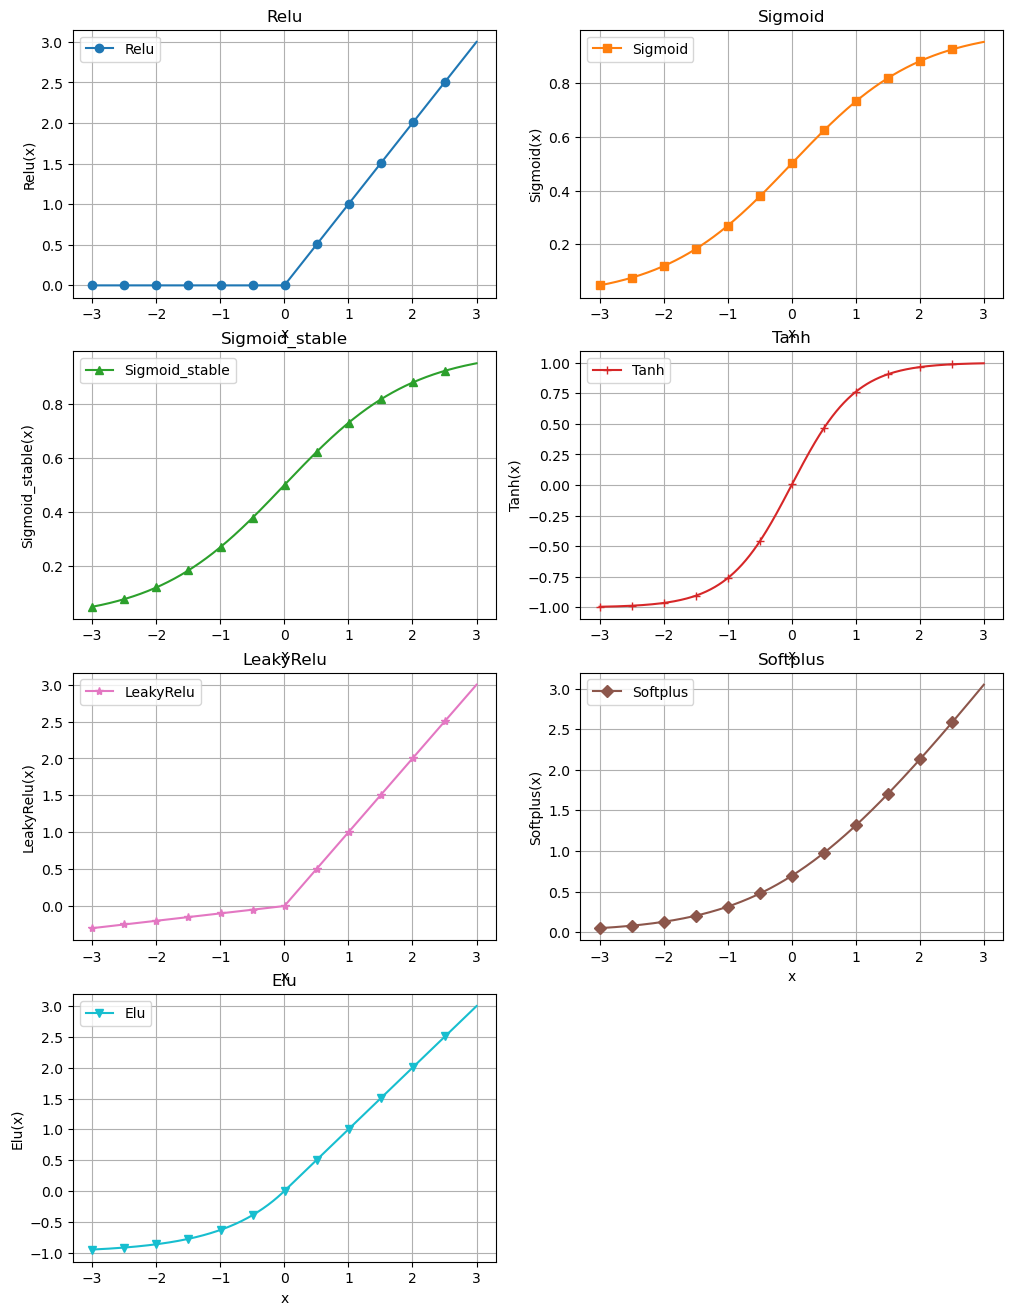

<Figure size 640x480 with 0 Axes>

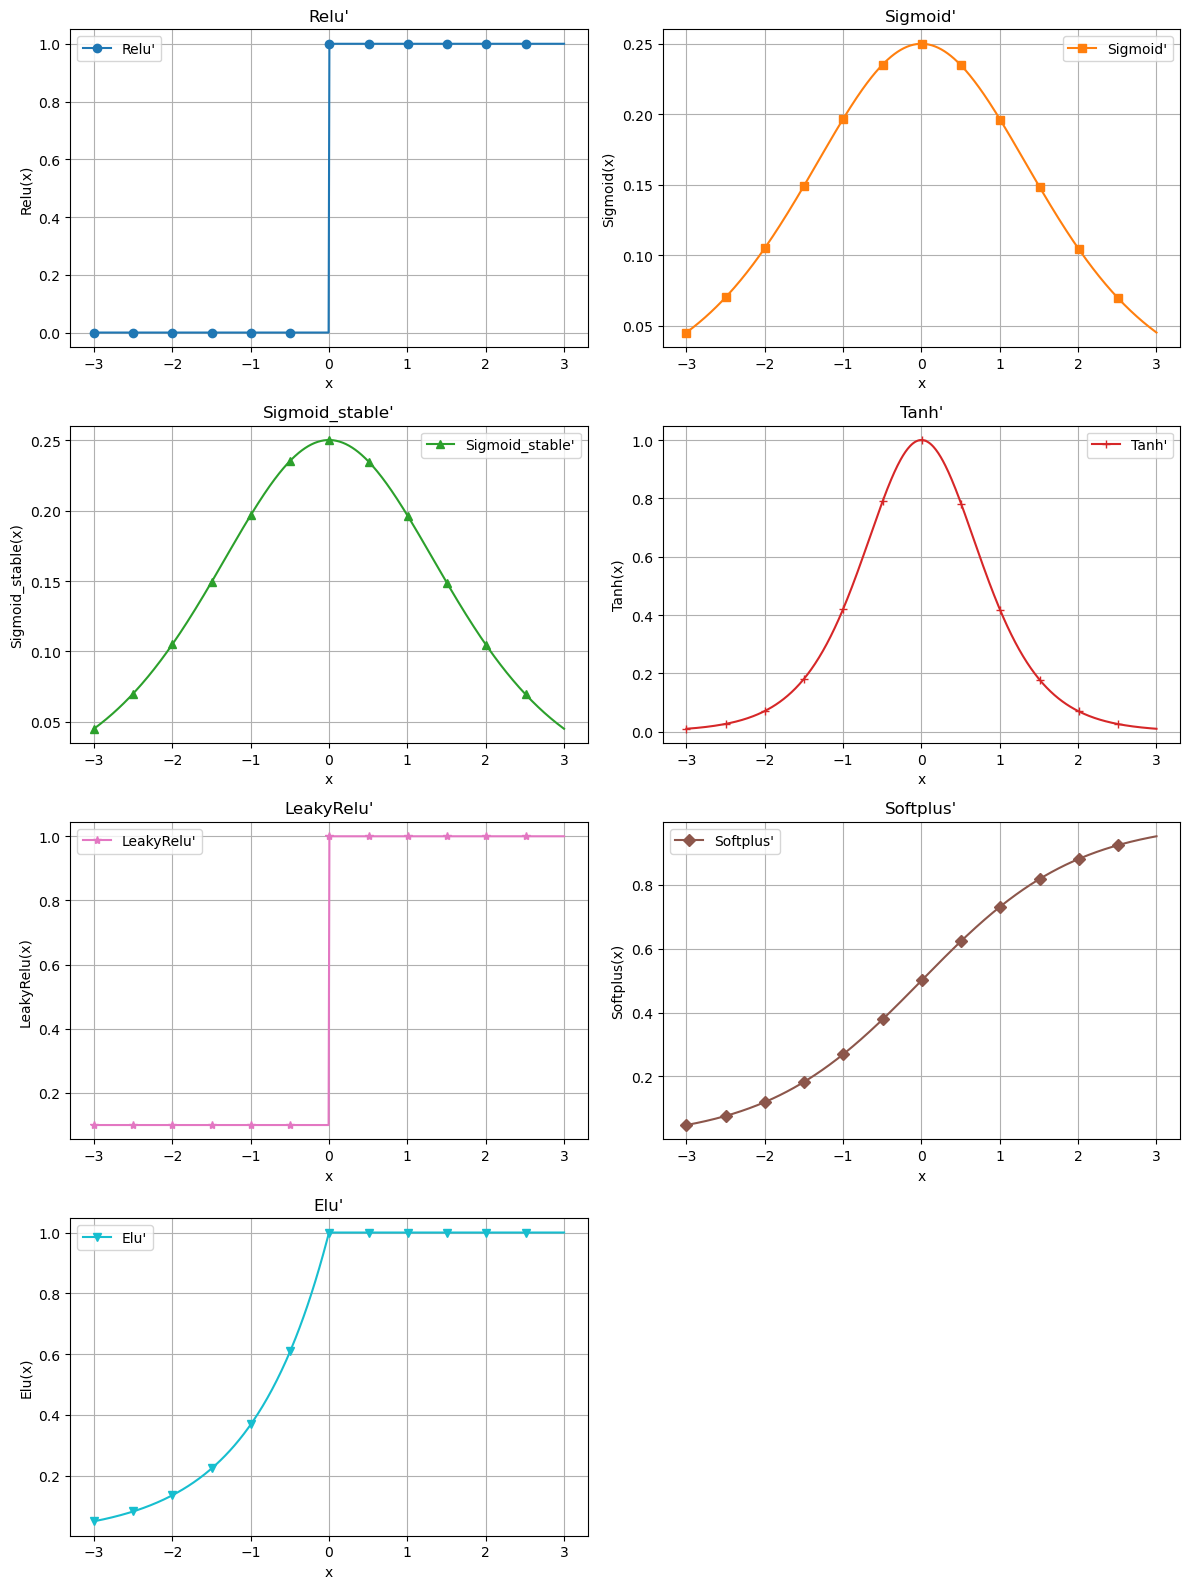

In [9]:
# TODO

fig, axes = plt.subplots(4,2, figsize = (12,16), sharex=False, sharey=False)
flat_ax = axes.ravel()

plt.figure(1)
for ax, name, activation, couleur, marker in zip(flat_ax, activations.keys(), activations.values(), couleurs.values(), markers.values()):
    ax.plot(x, activation(x), color = couleur, label = name, marker = marker, markevery = 50)
    ax.set_ylabel(f"{name}(x)")
    ax.set_xlabel("x")
    ax.set_title(name)
    ax.legend()
    ax.grid()

fig.delaxes(flat_ax[7])


plt.figure(2)
fig2, axes2 = plt.subplots(4,2, figsize = (12,16), sharex=False, sharey=False)
flat_ax2 = axes2.ravel()
for ax, name, d_activation, couleur, marker in zip(flat_ax2, d_activations.keys(), d_activations.values(), couleurs.values(), markers.values()):
    ax.plot(x, d_activation(x), color = couleur, label = name+"'", marker = marker, markevery = 50)
    ax.set_ylabel(f"{name}(x)")
    ax.set_xlabel("x")
    ax.set_title(name+"'")
    ax.legend()
    ax.grid()

fig2.delaxes(flat_ax2[7])

plt.tight_layout()
plt.show()


#### IV.3. Tracé comparatif par une Fonction `sub_tracer(rows, cols, mode="activation")`

##### ✅ À faire
Ecrire une fonction `sub_tracer(rows, cols, mode="activation")` permettant de tracer automatiquement, dans une grille de sous-graphes :

- les **fonctions d’activation**,
- ou leurs **dérivées**,
- ou **les deux** successivement.

---

##### ✅ Paramètres
- `rows` : nombre de lignes de la grille
- `cols` : nombre de colonnes de la grille
- `mode` : type de tracé à réaliser, avec l’une des valeurs suivantes :
  - `"activation"` : trace uniquement les **fonctions d’activation**
  - `"derivee"` : trace uniquement les **fonctions dérivées**
  - `"both"` : trace d’abord les **fonctions d’activation**, puis les **dérivées**

---


##### ✅ Appels attendus

```python
sub_tracer(4, 2, mode="activation")

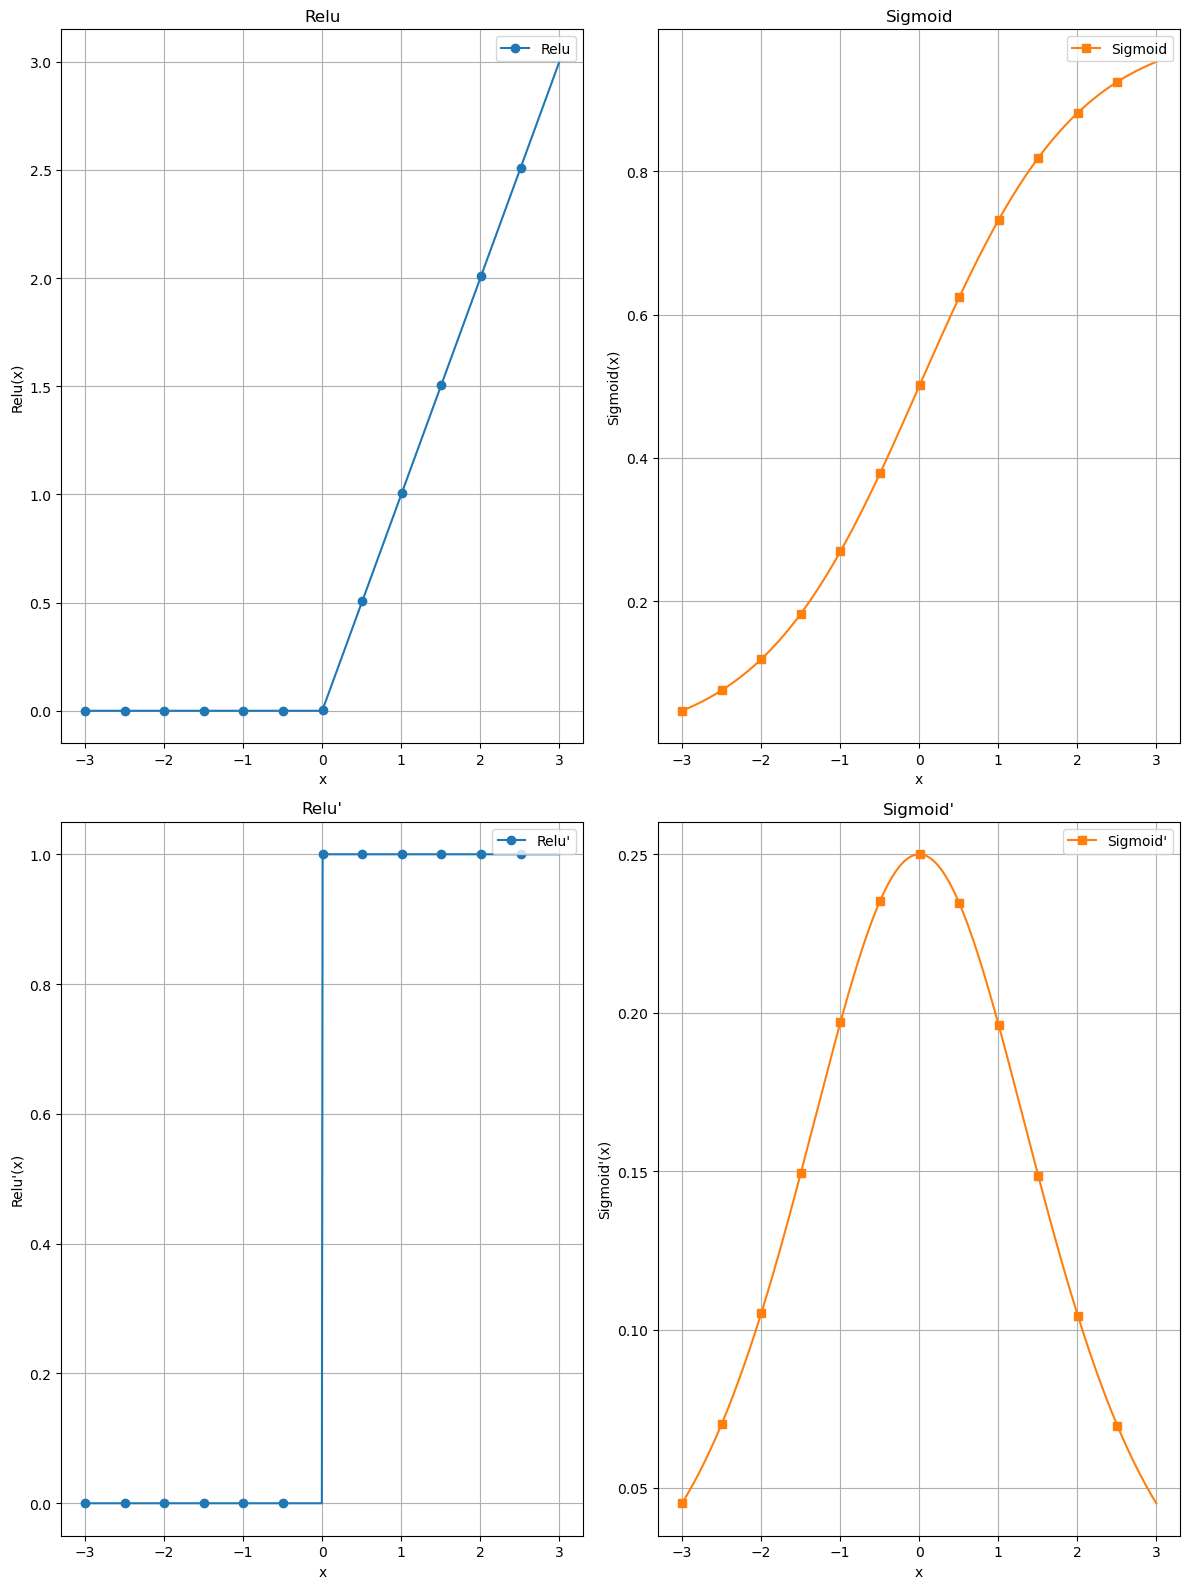

In [10]:
# TODO
def draw_plot(axes, functions, label):
    axes = np.array(axes).ravel()

    for ax, (name, func), couleur, marker in zip(
        axes,
        functions.items(),
        couleurs.values(),
        markers.values()
    ):
        ax.plot(
            x,
            func(x),
            color=couleur,
            marker=marker,
            markevery=50,
            label=name+label
        )

        ax.set_title(name + label)
        ax.set_xlabel("x")
        ax.set_ylabel(f"{name}{label}(x)")
        ax.legend()
        ax.grid(True)

def sub_tracer(rows, cols, mode="activation"):
    fig, axes = plt.subplots(rows, cols, figsize=(12, 16))

    match mode:

        case "activation":
            draw_plot(axes, activations, "")

        case "derivee":
            draw_plot(axes, d_activations, "'")

        case "both":
            flat = np.array(axes).ravel()
            half = len(flat) // 2

            draw_plot(flat[:half], activations, "")
            draw_plot(flat[half:], d_activations, "'")

        case _:
            print(f"{mode} is not valid")
            return

    plt.tight_layout()
    plt.show()

sub_tracer(2, 2, "both")

---
### V. Extension 2 - Implémentation Mini Réseau de Neurones (2 → 3 → 1) en NumPy pour l'apprentissage de XOR
#### V.1. Comprendre l’exemple XOR ($\oplus$)

##### a) Définition du problème XOR
On considère deux entrées binaires $x_1, x_2$. La sortie $y$ vaut 1 **si les deux entrées sont différentes**, sinon 0.

| $x_1$ | $x_2$ | $y = x_1 \oplus x_2$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

##### b) Pourquoi XOR ?
- Un modèle **linéaire** (sans couche cachée) ne peut pas résoudre XOR : le problème est **non-linéairement séparable**.
- En ajoutant une **couche cachée** + une **activation non-linéaire**, le réseau peut apprendre une transformation qui rend XOR résoluble.

##### c) Schéma du mini-réseau (2 → 3 → 1)
<img src="reseau_xor_2_3_1_poids_wij.png" height="200px">


---

#### V.2. Préparer le mini-dataset de la fonction XOR


In [11]:
# TODO
x = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

print(x.shape)
print(y.shape)

(4, 2)
(4, 1)


---
#### V.3. Visualiser les points XOR

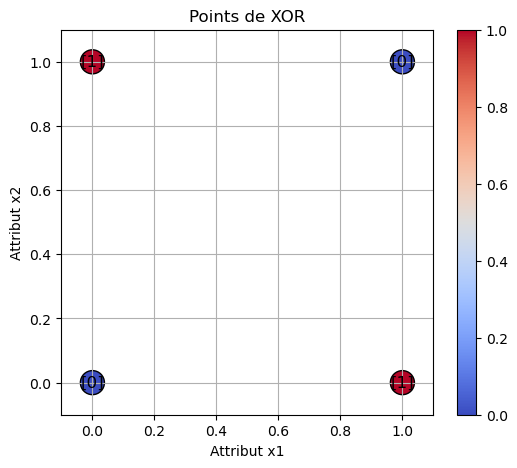

In [12]:
# XOR data
y_flat = y.ravel()

# grid coordinates
x1 = x[:,0]
x2 = x[:,1]

plt.figure(figsize=(6,5))

# draw grid lines
for i in [0, 1]:
    plt.plot([0, 1], [i, i], linestyle="None")
    plt.plot([i, i], [0, 1], linestyle="None")

# plot nodes (circles)
sc = plt.scatter(
    x1, x2,
    c=y,
    cmap="coolwarm",
    s=300,
    edgecolors="black"
)

# labels inside circles
for i in range(len(x)):
    plt.text(x1[i], x2[i], str(y[i]),
             ha='center', va='center',
             fontsize=12, color="black")

plt.title("Points de XOR")
plt.xlabel("Attribut x1")
plt.ylabel("Attribut x2")
plt.colorbar(sc)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.show()



#### V.4. Initialisation des paramètres (W1, b1, W2, b2)

##### ✅ Contraintes de dimensions (shapes)

Pour un lot de **N** exemples (*batch*), un réseau **2 → 3 → 1** implique :

- $X \in \mathbb{R}^{N \times 2}$
- $W_1 \in \mathbb{R}^{2 \times 3}$,  $b_1 \in \mathbb{R}^{3}$ *(ou $1 \times 3$)*
- $W_2 \in \mathbb{R}^{3 \times 1}$,  $b_2 \in \mathbb{R}^{1}$ *(ou $1 \times 1$)*

---

##### ✅ Shapes à chaque étape (forward)

1) **Couche 1 (linéaire)**  
$
Z_1 = XW_1 + b_1 \quad \Rightarrow \quad Z_1 \in \mathbb{R}^{N \times 3}
$

2) **Activation 1**  
$
A_1 = \sigma_1(Z_1) \quad \Rightarrow \quad A_1 \in \mathbb{R}^{N \times 3}
$

3) **Couche 2 (linéaire)**  
$
Z_2 = A_1W_2 + b_2 \quad \Rightarrow \quad Z_2 \in \mathbb{R}^{N \times 1}
$

4) **Activation 2 (sortie)**  
$
\hat{y} = \sigma_2(Z_2) \quad \Rightarrow \quad \hat{y} \in \mathbb{R}^{N \times 1}
$

---

#### 🔎 Cas XOR

Pour XOR, on a **$N = 4$**, donc :

- $X : (4, 2)$
- $Z_1, A_1 : (4, 3)$
- $Z_2, \hat{y} : (4, 1)$    

---

In [13]:
# TODO -  XOR : N=4, input_dim=2, hidden_dim=3, output_dim=1
np.random.seed(42)

data_config = {
    "N": x.shape[0],
    "input_dim": x.shape[1]
}
hyperparams = {
    "hidden_dim": 3,
    "output_dim": 1,
    "learning_rate": 0.8,
    "epochs": 4000
}

# TODO: initialiser W1, b1, W2, b2
input_dim = data_config["input_dim"]
hidden_dim = hyperparams["hidden_dim"]
output_dim = hyperparams["output_dim"]

# W1: (2,3)
W1 = np.random.randn(input_dim, hidden_dim) * 0.1

# b1: (1,3)
b1 = np.zeros((1, hidden_dim))

# W2: (3,1)
W2 = np.random.randn(hidden_dim, output_dim) * 0.1

# b2: (1,1)
b2 = np.zeros((1, output_dim))

# TODO - Vérification des shapes : W1: (2,3), b1: (1,3), W2: (3,1), b2: (1,1)
print(f"W1.shape: {W1.shape}    b1.shape = {b1.shape}")
print(f"W2.shape: {W2.shape}    b2.shape = {b2.shape}")

# TODO - Affichage de W1 , b1 , W2 , b2
print(f"W1: {W1}       b1 {b1}")
print(f"W2: {W2}       b2 {b2}")

W1.shape: (2, 3)    b1.shape = (1, 3)
W2.shape: (3, 1)    b2.shape = (1, 1)
W1: [[ 0.04967142 -0.01382643  0.06476885]
 [ 0.15230299 -0.02341534 -0.0234137 ]]       b1 [[0. 0. 0.]]
W2: [[ 0.15792128]
 [ 0.07674347]
 [-0.04694744]]       b2 [[0.]]


#### V.5. Choix des activations (une par couche)

##### ✅ Fonctions Activations recommandées et dérivées utiles

- **Couche cachée** : `tanh` *(ou `relu` ou `leaky-relu`)*
- **Couche de sortie** : `sigmoid` *(classification binaire)*

> Rappel : `sigmoid` renvoie une probabilité dans \([0,1]\), ce qui convient à une sortie binaire (0/1).

---

##### ✅ Dérivées (formes pratiques)

Dans le **backprop**, on utilise souvent une forme pratique des dérivées **en fonction de la sortie** (quand on a déjà calculé l’activation).

- Si $a = \tanh(z)$ alors :
$
\tanh'(z)=1-a^2
$

- Si $s = \sigma(z)$ alors :
$
\sigma'(z)=s(1-s)
$

---


##### 🧠 Cellule Python (à compléter)

In [14]:
# TODO
act_hid = activations["Tanh"]     # Tanh ou Relu ou Leaky-Relu
# sortie binaire -> Sigmoid ou Sigmoid_Stable
act_out = activations['Sigmoid']
d_act_hid = d_activations["Tanh"]
d_act_out = d_activations['Sigmoid']

---
#### V.6. Propagation avant (Forward pass)

##### ✅ Formules

Pour un réseau **2 → 3 → 1** :

###### 1) Pré-activation cachée (Couche cachée (linéaire))
$
Z_1 = XW_1 + b_1
$

- `X @ W1` réalise le **produit matriciel**.
- `+ b1` se fait par **broadcasting** sur les \(N\) lignes de \(Z_1\).

---

###### 2) Activation cachée
$
A_1 = \tanh(Z_1)
$

---

###### 3) Pré-activation de sortie (Couche de sortie (linéaire))
$
Z_2 = A_1W_2 + b_2
$

---

###### 4) Activation de sortie (Sortie probabiliste)
$
\hat{y} = \sigma(Z_2)
$

---

##### 🧠 Cellule Python (à compléter)


In [15]:
# TODO
def forward(x, W1, b1, W2, b2, act_hid, act_out):
    Z1 = x@W1+b1
    A1 = act_hid(Z1)
    Z2 = A1@W2+b2
    y_hat = act_out(Z2)
    cache = (x, Z1, A1, Z2, y_hat)
    return y_hat, cache


y_hat, cache = forward(x, W1, b1, W2, b2, act_hid, act_out)
y_hat

array([[0.5       ],
       [0.50579224],
       [0.50093505],
       [0.50666764]])

---
#### V.7. Fonction de perte \(L\) (MSE)

On utilise la **MSE** (*Mean Squared Error*) :

$
L = \frac{1}{N}\sum_{i=1}^{N}\left(\hat{y}_i - y_i\right)^2
$

- $N$ : nombre d’exemples
- $y$ : valeurs réelles (labels)
- $\hat{y}$ : prédictions du modèle

---

#### 🧠 Cellule Python (à compléter)

In [16]:
# TODO

def mse(y_hat, y):
    return np.mean((y_hat - y) ** 2)


print("Loss:", mse(y_hat, y))

Loss: 0.2500048076855083


#### V.8. Backpropagation (calcul détaillé)

##### ✅ Idée générale

On veut calculer les **gradients** des paramètres du réseau :

- $dW_2 = \dfrac{\partial L}{\partial W_2}$, $\;db_2 = \dfrac{\partial L}{\partial b_2}$
- $dW_1 = \dfrac{\partial L}{\partial W_1}$, $\;db_1 = \dfrac{\partial L}{\partial b_1}$

---

##### Etape 1 — Gradient de la loss par rapport à $\hat{y}$

Pour la MSE :
$
L = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2
$

Donc :
$
\frac{\partial L}{\partial \hat{y}} = \frac{2(\hat{y}-y)}{N}
$

En code : `dY`.

---

##### Etape 2 — Passer de $\hat{y}$ à $Z_2$ (sortie sigmoid)

$
\hat{y} = \sigma(Z_2)
\Rightarrow
dZ_2 = dY \odot \sigma'(Z_2)
$

Or :
$
\sigma'(Z_2) = \hat{y}(1-\hat{y})
$

Donc :
$
dZ_2 = dY \odot \hat{y}(1-\hat{y})
$

---

##### Etape 3 — Gradients de $W_2$ et $b_2$

Comme :
$
Z_2 = A_1W_2 + b_2
$

Alors :
$
dW_2 = A_1^T dZ_2
\qquad
db_2 = \sum_{i=1}^{N} dZ_2^{(i)}
$

- `A1.T @ dZ2` est un **produit matriciel**
- `np.sum(..., axis=0)` cumule sur les $N$ exemples

---

##### Etape 4 — Propager vers la couche cachée

D’abord :
$
dA_1 = dZ_2 W_2^T
$

Puis comme :
$
A_1 = \tanh(Z_1)
$

On utilise :
$
\tanh'(Z_1) = 1 - A_1^2
$

Donc :
$
dZ_1 = dA_1 \odot (1 - A_1^2)
$

---

##### Etape 5 — Gradients de \(W_1\) et \(b_1\)

Comme :
$
Z_1 = XW_1 + b_1
$

Alors :
$
dW_1 = X^T dZ_1
\qquad
db_1 = \sum_{i=1}^{N} dZ_1^{(i)}
$

---

#### V.9. Boucle d’entraînement (Gradient Descent)

##### ✅ Mise à jour des paramètres

$
W \leftarrow W - \eta\, dW
\qquad
b \leftarrow b - \eta\, db
$

où $\eta$ est le **learning rate**.

---

##### 🧠 Cellule Python (complète)

In [17]:
# TODO
def train(x, y, W1, b1, W2, b2, lr=0.8, epochs=2000, f_act_hid=act_hid, f_act_out=act_out, d_f_act_hid=d_act_hid, d_f_act_out=d_act_out):
    losses = []

    for epoch in range(epochs):
        # ---------- Forward ----------
        y_hat, (xc, Z1, A1, Z2, yhc) = forward(
            x, W1, b1, W2, b2, f_act_hid, f_act_out)

        # ---------- Loss ----------
        L = mse(y_hat, y)
        losses.append(L)

        # ---------- Backprop ----------
        N = y.shape[0]

        # dL/dy_hat
        dY = (2 / N) * (y_hat - y)              # Vecteur (N,1)

        # y_hat = sigmoid(Z2)
        #sigma = y_hat
        dZ2 = dY * d_act_out(Z2)          # Vecteur (N,1)

        # dW2, db2 (Z2 = A1W2 + b2)
        dW2 = A1.T @ dZ2                        # Vecteur (3,N)@(N,1) -> (3,1)
        db2 = np.sum(dZ2, axis=0, keepdims=True)        # (1,)

        # propagate to hidden
        dA1 = dZ2 @ W2.T                     # (N,1)@(1,3) -> (N,3)
        dZ1 = dA1 * d_f_act_hid(Z1)          # (N,3)

        # dW1, db1 (Z1 = XW1 + b1)
        dW1 = x.T @ dZ1                       # (2,N)@(N,3) -> (2,3)
        db1 = np.sum(dZ1, axis=0, keepdims=True)             # (3,)

        # ---------- Update ----------
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        if epoch % 400 == 0:
            print(f"epoch={epoch:4d}  loss={L:.6f}")

    return W1, b1, W2, b2, losses


W1t, b1t, W2t, b2t, losses = train(x, y, W1, b1, W2, b2, lr=hyperparams['learning_rate'], epochs=hyperparams['epochs'],
                                   f_act_hid=act_hid, f_act_out=act_out, d_f_act_hid=d_act_hid, d_f_act_out=d_act_out)
y_pred, _ = forward(x, W1, b1, W2, b2, act_hid, act_out)
print("Probas:\n", y_pred)
print("Classes:\n", (y_pred >= 0.5).astype(int))

epoch=   0  loss=0.250005
epoch= 400  loss=0.238034
epoch= 800  loss=0.007801
epoch=1200  loss=0.002238
epoch=1600  loss=0.001236
epoch=2000  loss=0.000839
epoch=2400  loss=0.000630
epoch=2800  loss=0.000502
epoch=3200  loss=0.000416
epoch=3600  loss=0.000355
Probas:
 [[0.02015912]
 [0.98574165]
 [0.98571903]
 [0.02053532]]
Classes:
 [[0]
 [1]
 [1]
 [0]]


#### V.10. Courbe de convergence de la loss

La courbe de convergence permet de visualiser l’évolution de la **fonction de perte (MSE)** au fil des **epochs**.  
Une loss qui diminue progressivement indique que l’entraînement converge.

---

##### 🧠 Cellule Python

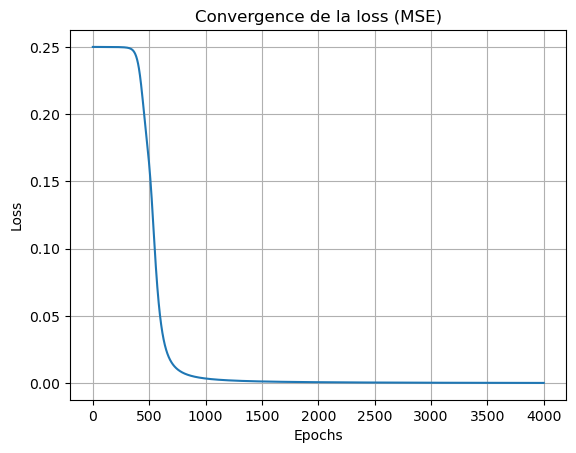

In [18]:
# TODO
plt.plot(losses)
plt.title("Convergence de la loss (MSE)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

## Partie B -  Extension : Dataset bruité + Evaluation du modèle

Dans cette partie, nous allons :

1. générer un **dataset XOR bruité**
2. séparer les données en **train / test**
3. entraîner le **mini réseau de neurones**
4. calculer les **prédictions**
5. évaluer le modèle avec :
   - accuracy
   - precision
   - recall
   - F1-score
   - matrice de confusion
   - courbe ROC et AUC

Cette partie simule une situation proche d'un **problème réel de classification supervisée**.

---

### I — Génération d’un dataset XOR bruité

#### I.1. Motivation

Dans un problème réel :

- les données sont dupliquées 
- les données contiennent du **bruit**
- certaines **étiquettes peuvent être erronées**

Nous allons donc modifier le dataset XOR original :

| x1 | x2 | y |
|----|----|---|
|0|0|0|
|0|1|1|
|1|0|1|
|1|1|0|

- En Dupliquant les données : répeter chaque coin `n` fois,
- En perturbant les données dupliquées : Deux types de perturbations seront ajoutés :

##### **Bruit sur les features**

On ajoute un bruit gaussien :

$
X_{bruit} = X + \epsilon
$

avec :

$
\epsilon \sim \mathcal{N}(0,\sigma^2)
$ Où  $\sigma = $ l'écart-type

##### **Labels erronés**

Avec une probabilité $p$, on inverse les labels :

$
y = 1 - y
$

---

#### I.2. Implémentation

In [19]:
# TODO


def make_noisy_xor(n=10, noise=0.08, flip=0.05, seed=0):
    rng = np.random.default_rng(seed)

    # XOR base dataset
    X_base = np.array([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ], dtype=float)

    y_base = np.array([
        [0],
        [1],
        [1],
        [0]
    ])

    # Duplicate each point n times
    x = np.repeat(X_base, n, axis=0)
    y = np.repeat(y_base, n, axis=0)

    # Add Gaussian noise to features
    x += rng.normal(0, noise, size=x.shape)

    # Flip labels with probability flip
    mask = rng.random(y.shape) < flip
    y[mask] = 1 - y[mask]

    return x, y

#### I.3. Génération du dataset

In [20]:
x, y = make_noisy_xor(n=100, noise=0.07, flip=0.05)
print(f"x.shape: {x.shape}")
print(x)

x.shape: (400, 2)
[[ 8.80111548e-03 -9.24734043e-03]
 [ 4.48295855e-02  7.34300820e-03]
 [-3.74968561e-02  2.53116538e-02]
 [ 9.12800032e-02  6.62956674e-02]
 [-4.92614665e-02 -8.85795030e-02]
 [-4.36292124e-02  2.89281855e-03]
 [-1.62752154e-01 -1.53154165e-02]
 [-8.72137663e-02 -5.12587148e-02]
 [-3.80981288e-02 -2.21410109e-02]
 [ 2.88141375e-02  7.29759359e-02]
 [-8.99742641e-03  9.56524429e-02]
 [-4.65636271e-02  2.46057049e-02]
 [ 6.32429127e-02  6.58086084e-03]
 [-5.20449475e-02 -6.45207763e-02]
 [-3.20408078e-02  1.54136586e-02]
 [-7.06732728e-02 -1.46422902e-02]
 [-1.11457507e-02  3.78591909e-02]
 [ 1.50261386e-02  2.48760896e-02]
 [-4.57680027e-02 -9.07295436e-03]
 [ 5.48782829e-02  1.04540180e-01]
 [-8.81345872e-02  1.05974664e-01]
 [ 9.42112797e-02  5.46917980e-02]
 [ 1.85118941e-02 -2.19745970e-02]
 [ 1.02061448e-01  1.37218082e-01]
 [ 1.26114441e-01  9.20572635e-02]
 [ 2.50166287e-02 -8.45823043e-02]
 [-3.11789318e-04  4.59532455e-02]
 [-9.01853025e-02  2.76585442e-02]
 [

### II — Séparation Train / Test

### II.1. Objectif

Afin d’évaluer correctement le modèle, il faut :

- ✅ entraîner le modèle sur le **train set**
- ✅ évaluer le modèle sur le **test set**

Cela permet d’estimer la **capacité de généralisation** du modèle.

#### II.2. Procédure

- mélanger les indices
- définir une proportion de test
- séparer les données

🧠 **Cellule Python**

In [21]:
# TODO
def split_dataset(x, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)

    n = len(x)

    # Shuffle indices
    indices = rng.permutation(n)

    cut = int(n * (1 - test_ratio))

    train_idx = indices[:cut]
    test_idx = indices[cut:]

    x_train = x[train_idx]
    y_train = y[train_idx]

    x_test = x[test_idx]
    y_test = y[test_idx]
    return x_train, x_test, y_train, y_test


x_train, x_test, y_train, y_test = split_dataset(x, y)

print("x_Train size :", x_train.shape)
print("x_Test size :", x_test.shape)
print("y_Train size :", y_train.shape)
print("y_Test size :", y_test.shape)

x_Train size : (320, 2)
x_Test size : (80, 2)
y_Train size : (320, 1)
y_Test size : (80, 1)


### III — Entraînement du modèle

On réutilise la fonction `train()` définie dans la partie A.

**Rappel des étapes :**
- Forward propagation
- Calcul de la loss
- Backpropagation
- Mise à jour des poids

🧠 **Cellule Python**


W1.shape: (2, 3)     b1.shape: (1, 3)
W2.shape: (3, 1)     b2.shape: (1, 1)
W1 =
 [[ 0.30471708 -1.03998411  0.7504512 ]
 [ 0.94056472 -1.95103519 -1.30217951]]
b1 =
 [[0. 0. 0.]]
W2 =
 [[ 0.1278404 ]
 [-0.31624259]
 [-0.01680116]]
b2 =
 [[0.]]
epoch=   0  loss=0.238251
epoch= 400  loss=0.049790
epoch= 800  loss=0.045663
epoch=1200  loss=0.045120
epoch=1600  loss=0.044937
epoch=2000  loss=0.044846
epoch=2400  loss=0.044790
epoch=2800  loss=0.044751
epoch=3200  loss=0.044722
epoch=3600  loss=0.044699


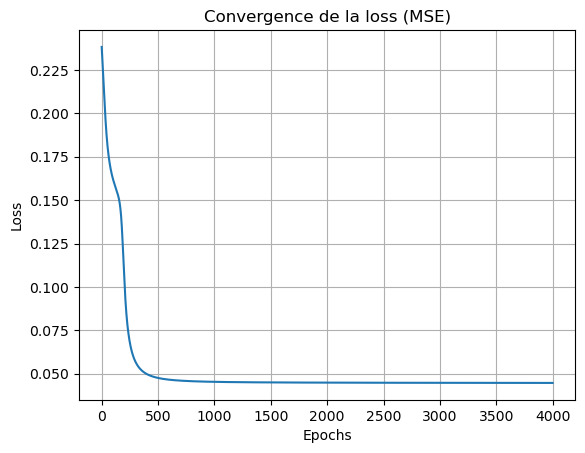

In [22]:
#  XOR : N=4, input_dim=2, hidden_dim=3, output_dim=1
data_config = {
    "N": x.shape[0],
    "input_dim": x.shape[1]
}
hyperparams = {
    "hidden_dim": 3,
    "output_dim": 1,
    "learning_rate": 0.8,
    "epochs": 4000
}
# TODO: initialiser W1, b1, W2, b2
rng = np.random.default_rng(42)

W1 = rng.normal(0, 1, (data_config["input_dim"], hyperparams["hidden_dim"]))
b1 = np.zeros((1, hyperparams["hidden_dim"]))

W2 = rng.normal(0, 1, (hyperparams["hidden_dim"], hyperparams["output_dim"]))
b2 = np.zeros((1, hyperparams["output_dim"]))
# TODO - Vérification des shapes : W1: (2,3), b1: (1,3), W2: (3,1), b2: (1,1)
print(f"W1.shape: {W1.shape}     b1.shape: {b1.shape}")
print(f"W2.shape: {W2.shape}     b2.shape: {b2.shape}")

# TODO - Affichage de W1 , b1 , W2 , b2
print("W1 =\n", W1)
print("b1 =\n", b1)
print("W2 =\n", W2)
print("b2 =\n", b2)

W1, b1, W2, b2, losses = train(
    x_train,
    y_train,
    W1,
    b1,
    W2,
    b2,
    lr=hyperparams["learning_rate"],
    epochs=hyperparams["epochs"],
    f_act_hid=act_hid,
    f_act_out=act_out,
    d_f_act_hid=d_act_hid,
    d_f_act_out=d_act_out
)

# TODO
plt.plot(losses)
plt.title("Convergence de la loss (MSE)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

### III — Prédictions du modèle

Après entraînement, on applique le modèle sur les données de test.

#### III.1 Calcul du score

Le réseau produit :

$
\hat{y} = P(y=1 \mid x)
$

C’est une **probabilité**.


### III.2. Conversion en classes

Pour obtenir une classification binaire :

$
\hat{y}=
\begin{cases}
1 & \text{si } p \ge 0.5 \\
0 & \text{sinon}
\end{cases}
$

🧠 **Cellule Python**
```python

In [23]:
y_score, _ = forward(x_test, W1, b1, W2, b2, act_hid, act_out)

threshold = 0.5
# TODO
y_pred_test = (y_score >= threshold).astype(int)

print(y_pred_test)

[[0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]]


### IV. Matrice de confusion : TP, TN, FP, FN

#### IV.1. Définitions (classe positive = 1)

La matrice de confusion compare :

- les **prédictions** du modèle
- les **vraies classes**

|            | Prédit 1 | Prédit 0 |
|------------|----------|----------|
| **Réel 1** | TP       | FN       |
| **Réel 0** | FP       | TN       |

- **TP (True Positives)** : vrais **1** prédits **1**
- **TN (True Negatives)** : vrais **0** prédits **0**
- **FP (False Positives)** : vrais **0** prédits **1**
- **FN (False Negatives)** : vrais **1** prédits **0**

#### IV.1. Calcul
🧠 **Cellule Python**

In [24]:
def confusion_matrix(y_true, y_pred):
    # TODO
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return TP, TN, FP, FN


TP, TN, FP, FN = confusion_matrix(y_test, y_pred_test)
print("TP :", TP)
print("TN :", TN)
print("FP :", FP)
print("FN :", FN)

TP : 30
TN : 42
FP : 5
FN : 3


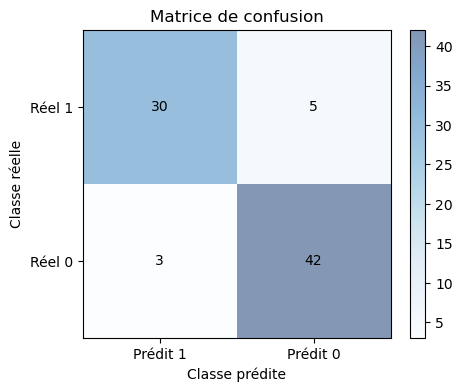

In [25]:
# TODO
# matrice de confusion
cm = np.array([
    [TP, FP],
    [FN, TN]
])

# matrice de confusion texts
cm_txt = np.array([
    [TP, FP],
    [FN, TN]
])

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues", alpha=0.5)
plt.title("Matrice de confusion")
plt.colorbar()

# étiquettes des axes
plt.xticks([0, 1], ["Prédit 1", "Prédit 0"])
plt.yticks([0, 1], ["Réel 1", "Réel 0"])

# afficher les valeurs dans chaque case
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm_txt[i, j], ha="center", va="center")

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

### V — Métriques de classification

#### **Accuracy**
$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$

#### **Precision**
$
Precision=\frac{TP}{TP+FP}
$

#### **Recall**
$
Recall=\frac{TP}{TP+FN}
$

#### **F1 Score**
$
F1=\frac{2 \cdot Precision \cdot Recall}{Precision + Recall}
$

🧠 **Cellule Python**


In [26]:
def classification_metrics(TP, TN, FP, FN):
    # TODO
    eps = 1e-12  # to avoid division by zero

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = TP / (TP + FP + eps)

    recall = TP / (TP + FN + eps)

    f1 = 2 * (precision * recall) / (precision + recall + eps)

    return accuracy, precision, recall, f1


accuracy, precision, recall, f1 = classification_metrics(TP, TN, FP, FN)

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1        :", f1)

Accuracy  : 0.9
Precision : 0.8571428571428326
Recall    : 0.9090909090908815
F1        : 0.8823529411759451


### VI. Courbe ROC

La courbe **ROC** (Receiver Operating Characteristic) analyse le comportement du modèle pour **différents seuils** de décision.

Pour chaque seuil \(t\) :

- convertir les probabilités en classes ($\hat{y} = 1$ si $p \ge t$, sinon 0)
- calculer $TP, TN, FP, FN$
- calculer **TPR** et **FPR**

#### VI.1. Définitions

$
TPR=\frac{TP}{TP+FN}
$

$
FPR=\frac{FP}{FP+TN}
$

#### VI.2. Calcul de **TPR** et **FPR**
🧠 **Cellule Python**


In [27]:
def roc_curve(y_true, y_score):
    thresholds = np.linspace(1, 0, 200)

    TPR = []
    FPR = []

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)

        TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
        # TODO
        # compute rates
        tpr = TP / (TP + FN + 1e-12)
        fpr = FP / (FP + TN + 1e-12)

        TPR.append(tpr)
        FPR.append(fpr)

    return np.array(FPR), np.array(TPR)

#### VI.3. Tracé de la ROC

🧠 **Cellule Python**


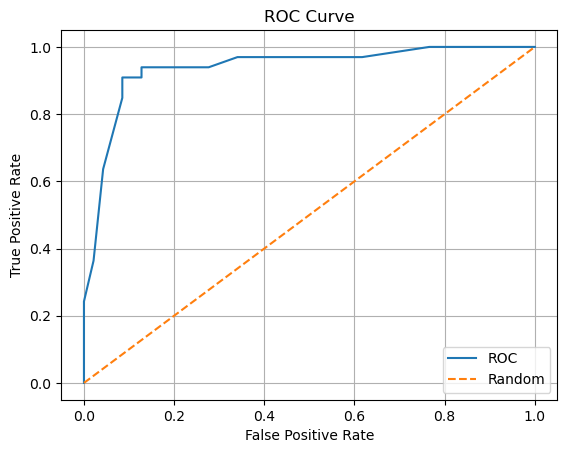

In [28]:
FPR, TPR = roc_curve(y_test, y_score)

# TODO
plt.Figure(figsize=(5, 4))
plt.plot(FPR, TPR, label="ROC")
plt.plot([0, 1], [0, 1], "--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

#### VI.4. Calcul de l'AUC

L’**AUC** (Area Under the Curve) mesure l’aire sous la courbe ROC.  


##### **Interprétation**

Plus L’**AUC** est proche de **1**, meilleur est le modèle :

- AUC ≈ 1 : excellent
- AUC ≈ 0.5 : aléatoire
- AUC < 0.5 : mauvais

🧠 **Cellule Python**


In [29]:
import scipy.integrate as integr
auc = integr.trapezoid(TPR, FPR)
print("AUC =", auc)

AUC = 0.9371373307543036
